In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
myData = pd.read_csv("Coding2_Data.csv")
var_names = myData.columns
y = myData[['Y']].to_numpy()
X = myData.drop(['Y'], axis = 1).to_numpy()

In [3]:
X.shape, len(y)

((506, 13), 506)

In [4]:
def one_var_lasso(v, z, lam):
    v = v.flatten()
    z = z.flatten()
    n = v.shape[0]
    b = np.dot(v,z) / np.dot(z,z)
    new_lam = 2 * n * lam / np.dot(z,z)
    return np.sign(b) * max(np.abs(b) - new_lam / 2, 0)

In [5]:
def MyLasso(X, y, lam_seq, maxit = 100):
    
    # Input
    # X: n-by-p design matrix without the intercept 
    # y: n-by-1 response vector 
    # lam.seq: sequence of lambda values (arranged from large to small)
    # maxit: number of updates for each lambda 
    
    # Output
    # B: a (p+1)-by-len(lam.seq) coefficient matrix 
    #    with the first row being the intercept sequence 

  
    n, p = X.shape
    nlam = len(lam_seq)
    B = np.zeros((p+1, nlam))
    
    
    ##############################
    # YOUR CODE: 
    # (1) newX = Standardizad X; 
    # (2) Record the centers and scales used in (1) 
    ##############################
    means = np.mean(X, axis=0)
    scales = np.std(X, axis=0, ddof=1)
    
    # Standardize the matrix
    newX = (X - means) / scales
    

    # Initilize coef vector b and residual vector r
    b = np.zeros(p)
    r = y

    
    # Triple nested loop
    for m in range(nlam):
        for step in range(maxit):
            for j in range(p):
                X_j = newX[:, j].reshape(-1,1)
                r = r + X_j * b[j]
                b[j] = one_var_lasso(r, X_j, lam_seq[m])
                r = r - X_j * b[j]
        B[1:, m] = b 
    
    for m in range(nlam):
        intercept = y.mean() - np.sum(B[1:, m] * means / scales)
        B[0, m] = intercept
        B[1:, m] = B[1:, m] / scales
    return (B)

In [6]:
log_lam_seq = np.linspace(-1, -8, num = 80)
lam_seq = np.exp(log_lam_seq)
myout = MyLasso(X, y, lam_seq, maxit = 100)

In [7]:
print(myout.shape)

(14, 80)


(14, 80)


(-8.35, -0.6499999999999999, -0.30998487507254924, 0.49975437052781413)

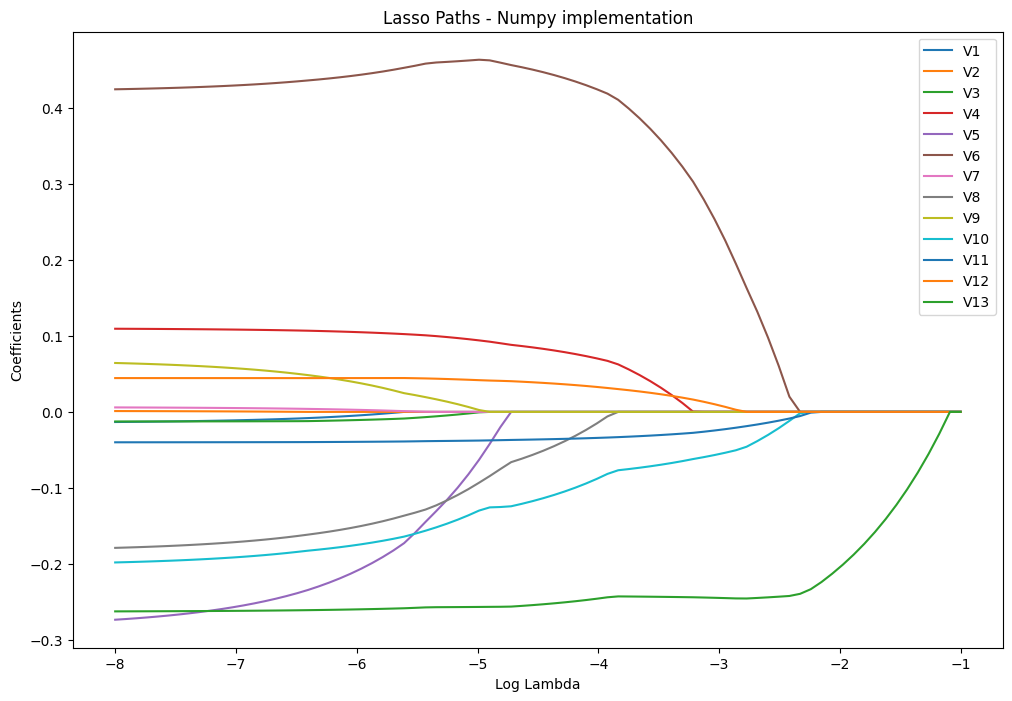

In [8]:
p, _ = myout.shape
print(myout.shape)
plt.figure(figsize = (12,8))

for i in range(p-1):
    plt.plot(log_lam_seq, myout[i+1, :], label = var_names[i])

plt.xlabel('Log Lambda')
plt.ylabel('Coefficients')
plt.title('Lasso Paths - Numpy implementation')
plt.legend()
plt.axis('tight')

In [9]:
lasso_coef = pd.read_csv("Coding2_lasso_coefs.csv").to_numpy()
lasso_coef.shape

(14, 80)

In [10]:
abs(myout - lasso_coef).max()


0.004563620189192541